# Replay analysis — one Kaggle episode

Parses replay JSON from `kaggle_logs/<submission_id>/replays/` (both players' private state + actions).

Batch summary for all episodes in a submission:

```bash
scripts/summarize_replays.sh <submission_id> --us-name "Your Name"
# writes kaggle_logs/<submission_id>/<submission_id>.json

cd scripts && python -m replay_analysis ../kaggle_logs/<submission_id> --us-name "Your Name"
```

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
if not (ROOT / "agent").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))

from replay_analysis import (
    analyze,
    plot_earnings_by_day,
    plot_earnings_by_zone,
    plot_game,
    plot_worker_actions,
)
from replay_analysis.load import SEASON_DAYS, load_replay

SUBMISSION_ID = "56575025"
EPISODE_ID = "113725010"  # from episodes.csv or replay filename
US_NAME = "Milos Vlainic"  # optional; matches info.TeamNames

REPLAY = ROOT / f"kaggle_logs/{SUBMISSION_ID}/replays/episode-{EPISODE_ID}-replay.json"
print(REPLAY, REPLAY.exists())

[zoning] CURRENT=TWO tiles=50 hands=9 KAGGRI_LANDS=2 ZONE_OPS_MIX=1
/media/wlaki/W/DS_projects/Kaggle/kaggriculture/kaggle_logs/56575025/replays/episode-113725010-replay.json True


In [3]:
report = analyze(REPLAY, us_name=US_NAME)
print(
    f"episode={report['episode_id']} seed={report['seed']} "
    f"rewards={report['rewards']} us_index={report['us_index']}"
)
us = report["us_index"] or 0
print(f"PASS total: {report['passes']['by_player'][us]['total']}")
print(f"Sold (filled): {report['sells']['by_player'][us]['filled_units']}")
print(f"End shed: {report['shed_end']['by_player'][us]['combined']}")

episode=113725010 seed=1516441049 rewards=[119482.0, 58260.0] us_index=1
PASS total: 1311
Sold (filled): {'CARROT': 25, 'EGG': 158, 'WHEAT': 72, 'FERTILIZER': 145, 'TOMATO': 78, 'MILK': 78, 'MELON': 24, 'WOOL': 50, 'STRAWBERRY': 22}
End shed: {'FERTILIZER': 2, 'CARROT': 4, 'TOMATO': 2, 'WHEAT': 6, 'WOOL': 6}


/media/wlaki/W/DS_projects/Kaggle/kaggriculture/scripts/replay_analysis/plot.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


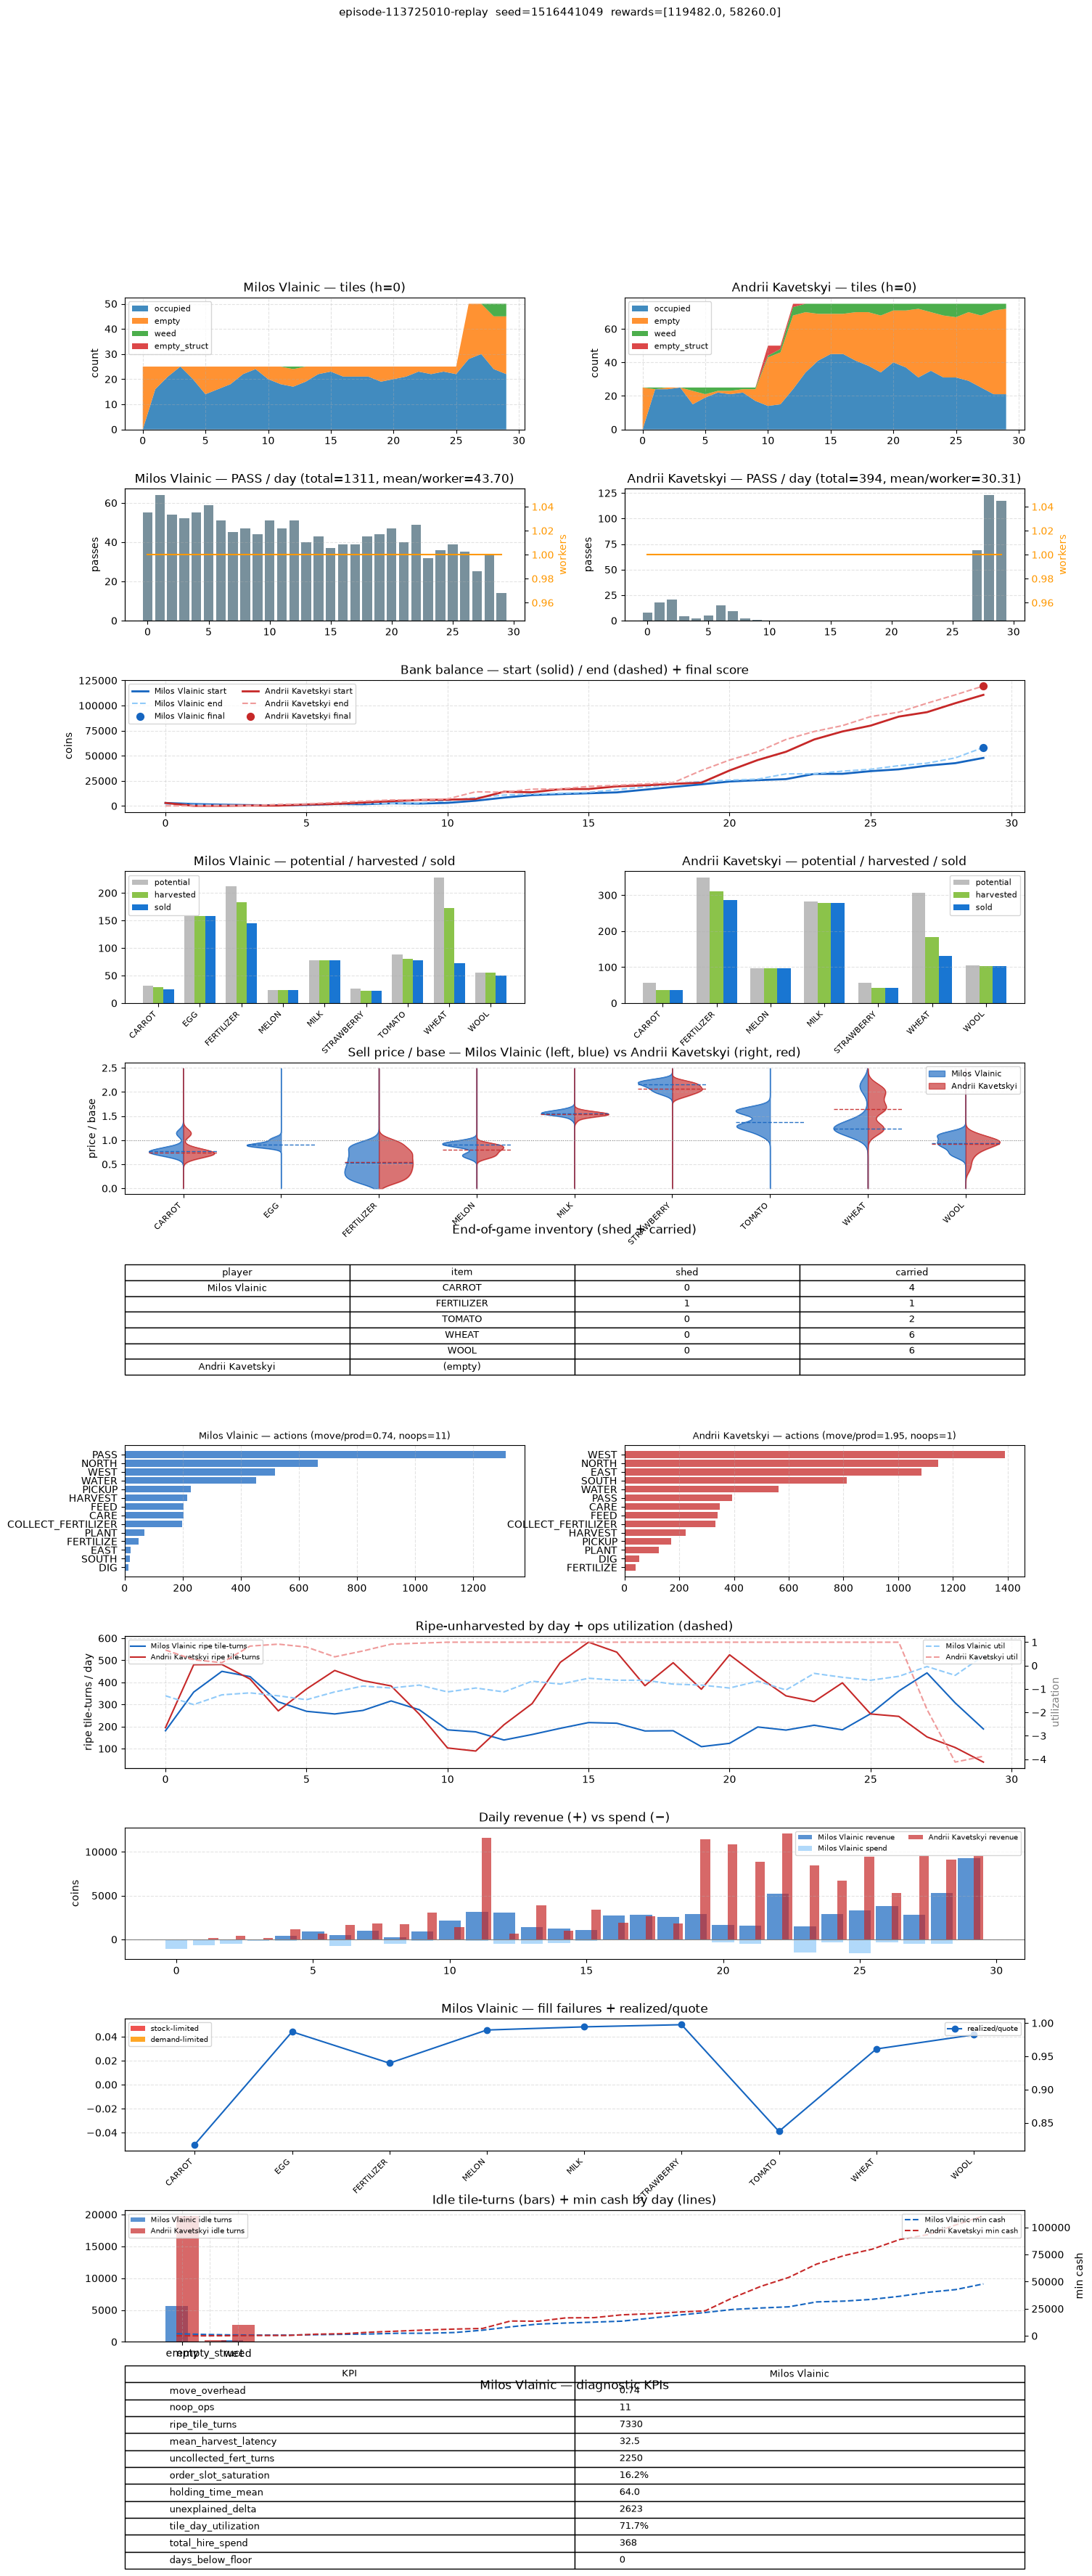

In [4]:
plot_game(report)

[zoning] CURRENT=milos_twoland12 tiles=50 hands=11


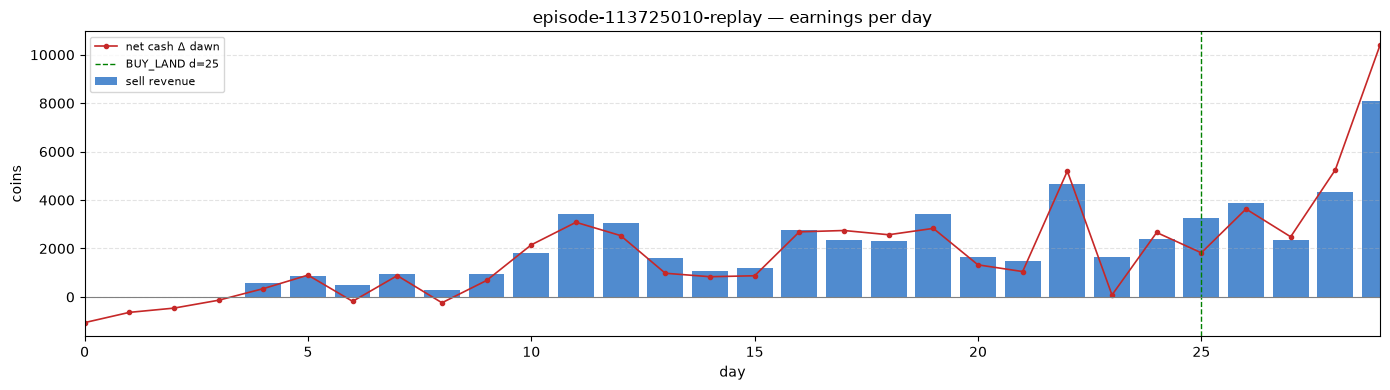

In [5]:
plot_earnings_by_day(report)

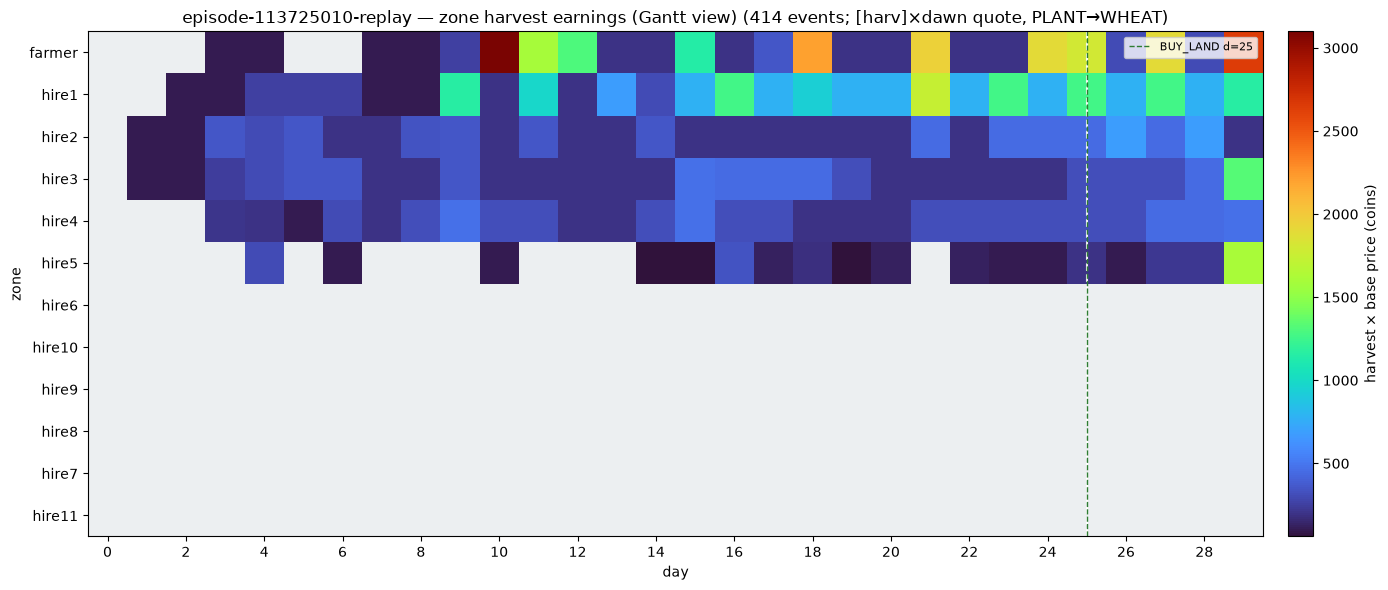

In [6]:
plot_earnings_by_zone(report)

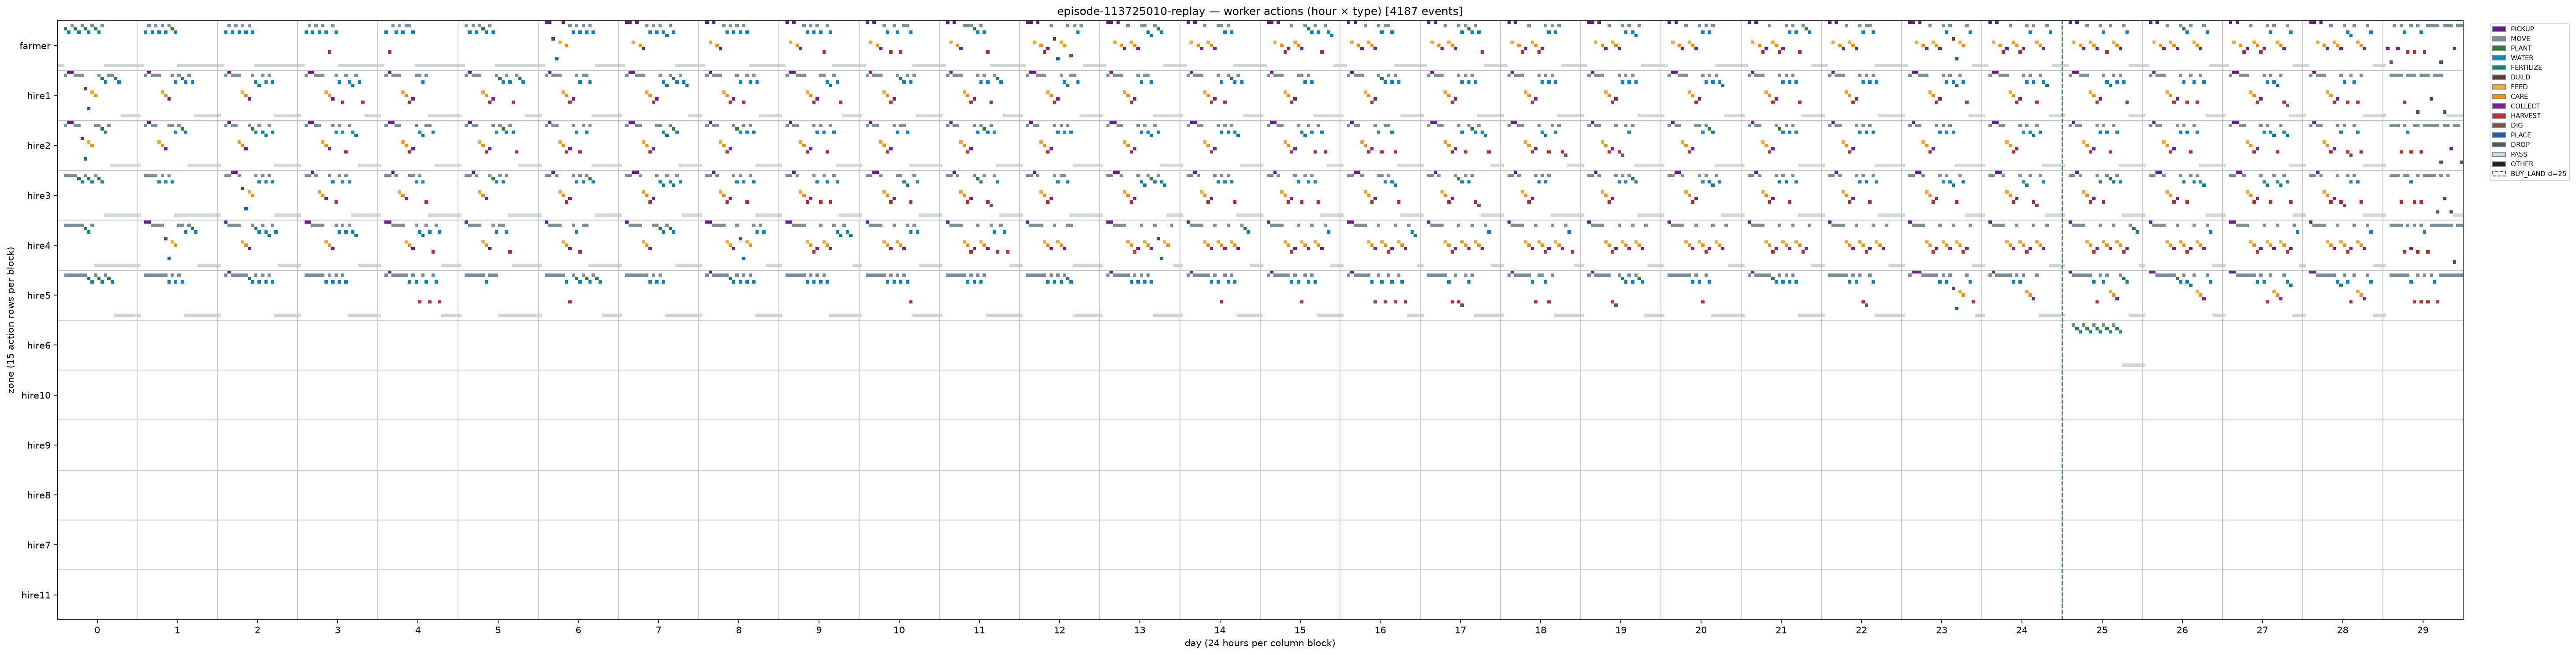

In [7]:
plot_worker_actions(report)

## Total tile ops / day — us vs opponent

Farm-wide **tile_ops only** (no MOVE / PASS) for this episode: us vs opponent.

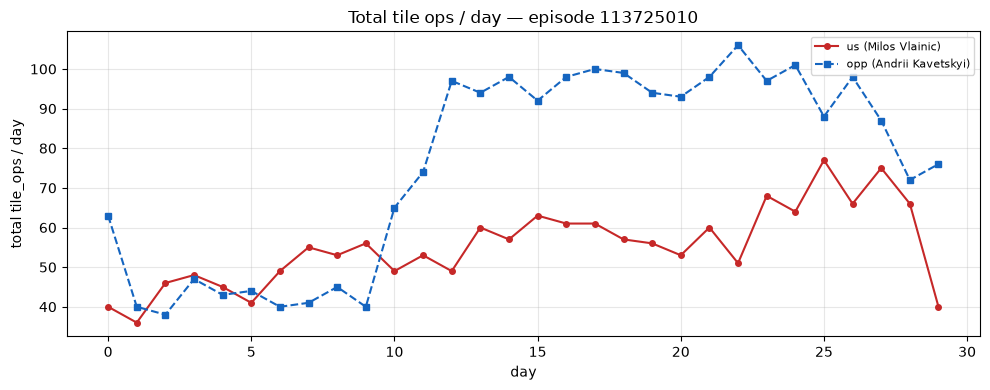

us mean=55.2  opp mean=75.6


In [8]:
from smoke_analysis.parse_actions import classify_action
from replay_analysis.metrics import _iter_unit_actions


def tile_ops_by_day(replay_path, player: int) -> list[float]:
    """Count non-MOVE/PASS farm actions per day (layout-agnostic)."""
    out = [0.0] * SEASON_DAYS
    for rec in load_replay(replay_path).iter_player(int(player)):
        day = int(rec.observation.get("day", 0))
        if not (0 <= day < SEASON_DAYS):
            continue
        for _who, action in _iter_unit_actions(rec):
            if not action:
                continue
            bucket = classify_action(str(action[0]))
            if bucket not in ("MOVE", "PASS"):
                out[day] += 1.0
    return out


us = int(report["us_index"] or 0)
opp = 1 - us
agents = report.get("agents") or ["us", "opp"]
us_label = agents[us] if us < len(agents) else "us"
opp_label = agents[opp] if opp < len(agents) else "opp"

us_ops = tile_ops_by_day(REPLAY, us)
opp_ops = tile_ops_by_day(REPLAY, opp)
days = np.arange(SEASON_DAYS)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(days, us_ops, "o-", color="#c62828", ms=4, label=f"us ({us_label})")
ax.plot(days, opp_ops, "s--", color="#1565c0", ms=4, label=f"opp ({opp_label})")
ax.set_xlabel("day")
ax.set_ylabel("total tile_ops / day")
ax.set_title(f"Total tile ops / day — episode {EPISODE_ID}")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"us mean={np.mean(us_ops):.1f}  opp mean={np.mean(opp_ops):.1f}")